#1: Importación

In [8]:
# manejo de directorios
import os

# calculo cientifico y vectorial
import numpy as np

# lectura y limpieza de datos
import pandas as pd

# graficos
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

# graficas en notebook
%matplotlib inline

# montar google drive
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


#1.1: Carga dee datos

In [9]:
# ruta del dataset
ruta_archivo = '/content/gdrive/MyDrive/Colab Notebooks/machine learning/datasets/transcoding_mesurment.tsv'

# cargar datos
print("cargando archivo\n")
df = pd.read_csv(ruta_archivo, sep='\t')

# eliminar nulos
df = df.dropna()

# columnas del dataset
print("columnas:")
print(df.columns.tolist())
print("-" * 30)

nombre_objetivo = 'utime'

# separar x e y
y_pandas = df[nombre_objetivo]
X_pandas = df.drop([nombre_objetivo], axis=1)

# eliminar id si existe
if 'id' in X_pandas.columns:
    X_pandas = X_pandas.drop(['id'], axis=1)

# one-hot encoding en x
X_pandas = pd.get_dummies(X_pandas)

# conversion a numpy
X = X_pandas.to_numpy(dtype=float)
y = y_pandas.to_numpy(dtype=float)

# dimensiones
m = y.size
n = X.shape[1]

print(f"filas (m) = {m}")
print(f"caracteristicas (n) = {n}")
print("-" * 30)

if m >= 20000 and n >= 20:
    print("cumple requisitos")
else:
    print("no cumple requisitos")

cargando archivo

columnas:
['id', 'duration', 'codec', 'width', 'height', 'bitrate', 'framerate', 'i', 'p', 'b', 'frames', 'i_size', 'p_size', 'b_size', 'size', 'o_codec', 'o_bitrate', 'o_framerate', 'o_width', 'o_height', 'umem', 'utime']
------------------------------
filas (m) = 68784
caracteristicas (n) = 26
------------------------------
cumple requisitos


#2: Normalización de Características

In [10]:
def featureNormalize(X):
    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# normalizar caracteristicas
X_norm, mu, sigma = featureNormalize(X)

# agregar columna de unos
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print("normalizacion completada")
print(f"columnas de x = {X.shape[1]}")

print("\nprimeros 5 valores fila 0:")
print(X[0][:5])

normalizacion completada
columnas de x = 27

primeros 5 valores fila 0:
[ 1.         -0.54326973 -0.96927335 -1.11619663 -0.5833334 ]


#3: Descenso por el gradiente

In [11]:
# funcion de costo
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = 0

    # error cuadratico medio
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

# descenso por el gradiente
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        # actualizacion de parametros
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)

        # historial de costo
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

print("funciones cargadas")

funciones cargadas


#4:Entrenamiento y Gráfica

entrenando modelo

entrenamiento completado



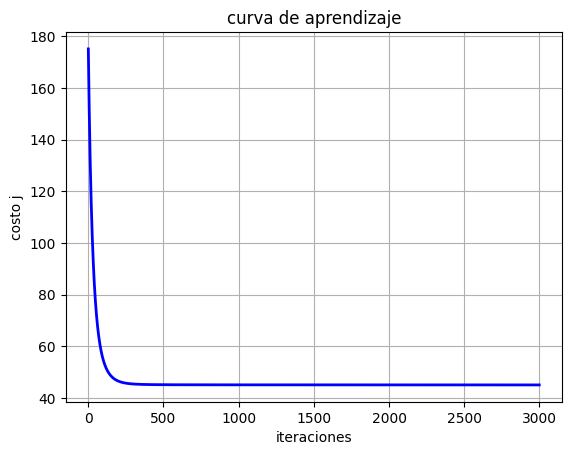


theta:
[ 9.99635482  0.34744251  0.75179649 -0.42594503  1.86854696  0.49939967
 -0.83491926  0.32091945  0.12386451  0.30724003 -0.68304465  0.22082542
  0.          0.15367911  2.48987324  1.65905896  3.14891303  2.62668066
  6.85829977  0.05665258  0.18440724  0.06289582 -0.29989119 -2.53045597
  2.65847689 -1.33907025  1.21455869]
----------------------------------------
comprobacion:
tiempo predicho: 2.69 s
tiempo real: 6.32 s
----------------------------------------


In [12]:
# hiperparametros
alpha = 0.01
num_iters = 3000

# inicializacion de theta
theta = np.zeros(X.shape[1])

print("entrenando modelo\n")
# descenso por el gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)
print("entrenamiento completado\n")

# curva de aprendizaje
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('iteraciones')
pyplot.ylabel('costo j')
pyplot.title('curva de aprendizaje')
pyplot.grid(True)
pyplot.show()

# parametros theta calculados
print('\ntheta:')
print(theta)

# ==========================================
# prediccion
# ==========================================
fila_ideal = np.argmax(y > 4)
tiempo_predicho = np.dot(X[fila_ideal], theta)
tiempo_real = y[fila_ideal]

print("-" * 40)
print("comprobacion:")
print(f"tiempo predicho: {tiempo_predicho:.2f} s")
print(f"tiempo real: {tiempo_real:.2f} s")
print("-" * 40)

#5:ecuacion de la normal

In [13]:
print("calculando parametros con ecuacion de la normal\n")

# ecuacion normal
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

# calculo de parametros
theta_normal = normalEqn(X, y)

# theta calculado
print('theta:')
print(theta_normal)

# prediccion
fila_prueba = np.argmax(y > 4)
tiempo_predicho_norm = np.dot(X[fila_prueba], theta_normal)

print("-" * 50)
print("comprobacion (ecuacion de la normal):")
print(f"tiempo predicho: {tiempo_predicho_norm:.2f} s")
print(f"tiempo real: {y[fila_prueba]:.2f} s")
print("-" * 50)

calculando parametros con ecuacion de la normal

theta:
[ 9.99635482e+00  2.78298450e-01  4.27428957e+00 -4.11761105e+00
  1.86130550e+00  5.50493093e-01 -6.61722773e-01  2.60256233e-01
  4.12947229e-03  2.47926393e-01 -5.29332035e+00 -5.38808223e+01
 -2.55405507e-09  5.75771176e+01  2.48984082e+00  1.65937605e+00
  4.48433064e+00  1.29156373e+00  6.85780156e+00 -4.30761436e-02
  3.10243693e-01 -1.65382316e-01 -1.78306089e-01 -2.53050105e+00
  2.65895420e+00 -1.33920844e+00  1.21426650e+00]
--------------------------------------------------
comprobacion (ecuacion de la normal):
tiempo predicho: 2.71 s
tiempo real: 6.32 s
--------------------------------------------------


caracteristica mas importante: 'umem'
columna en x: 18


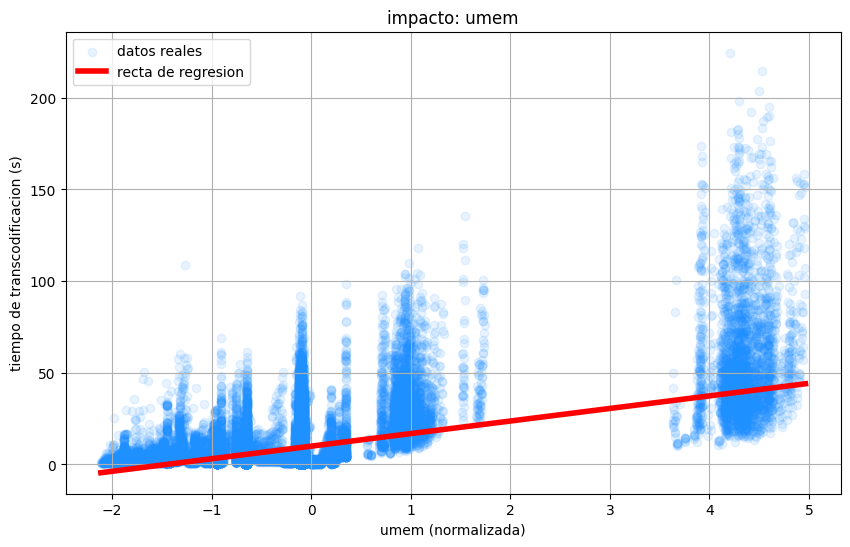

In [14]:
# corte 2d regresion lineal
import matplotlib.pyplot as plt
import numpy as np

# caracteristica de mayor peso
indice_mejor_feature = np.argmax(np.abs(theta[1:])) + 1
nombre_columna = X_pandas.columns[indice_mejor_feature - 1]
peso_mejor = theta[indice_mejor_feature]

print(f"caracteristica mas importante: '{nombre_columna}'")
print(f"columna en x: {indice_mejor_feature}")

# vector de la caracteristica principal
X_principal = X[:, indice_mejor_feature]

# configuracion del grafico
plt.figure(figsize=(10, 6))

# dispersion de datos reales
plt.scatter(X_principal, y, alpha=0.1, color='dodgerblue', label='datos reales')

# calculo de la recta
x_min = np.min(X_principal)
x_max = np.max(X_principal)

y_min_linea = theta[0] + (peso_mejor * x_min)
y_max_linea = theta[0] + (peso_mejor * x_max)

plt.plot([x_min, x_max], [y_min_linea, y_max_linea], color='red', linewidth=4, label='recta de regresion')

# etiquetas y formato
plt.title(f'impacto: {nombre_columna}')
plt.xlabel(f'{nombre_columna} (normalizada)')
plt.ylabel('tiempo de transcodificacion (s)')
plt.legend()
plt.grid(True)

plt.show()